# MaldiAMRKit - Drift Monitoring

This notebook demonstrates `maldiamrkit.drift.DriftMonitor`, which anchors
a baseline on the earliest timestamps and tracks temporal drift through
three complementary views:

- **Reference similarity** - distance of per-window median spectrum to
  the baseline reference (no labels needed)
- **PCA centroid trajectory** - how windows move in a baseline-fitted
  PCA space
- **Peak-selection stability + effect-size drift** - Jaccard overlap of
  top-k discriminative peaks per window vs. baseline, and Cohen's d of
  specific peaks over time

## Dataset

These notebooks use the **MALDI-Kleb-AI** dataset (Rocchi *et al.*, 2026; [Zenodo DOI 10.5281/zenodo.17405072](https://zenodo.org/records/17405072)), a curated archive of MALDI-TOF spectra of *Klebsiella* clinical isolates from three Italian centres (Rome, Milan, Catania) with Amikacin / Meropenem resistance annotations. For simplicity we restrict the demo to the **Rome sub-cohort** (single site, no batch correction needed). The helper in [`notebooks/_demo.py`](_demo.py) caches the 370 MB tarball under `~/.cache/maldiamrkit/` (or `$MALDIAMRKIT_CACHE_DIR`) on first use.

## Load the Dataset

We load the Rome cohort. The Zenodo metadata does not expose an
acquisition timestamp, so we **simulate dates** by spreading the real
spectra uniformly across a six-month window. The spectra themselves are
real clinical isolates; only the time axis is synthetic, which lets us
demonstrate the `DriftMonitor` API end-to-end without fabricating data.

In [1]:
import pathlib
import sys

import numpy as np
import pandas as pd

from maldiamrkit.susceptibility import LabelEncoder

sys.path.insert(0, str(pathlib.Path.cwd()))  # _demo.py sits next to this notebook
from _demo import load_maldi_kleb_ai

ds = load_maldi_kleb_ai(antibiotic="Amikacin", verbose=True)
encoder = LabelEncoder(intermediate="nan")
y = (
    pd.Series(
        encoder.fit_transform(ds.meta["Amikacin"]),
        index=ds.meta.index,
        name="Amikacin",
    )
    .dropna()
    .astype(int)
)
X = ds.X.loc[y.index]
print(f"Rows: {X.shape}, class counts: {y.value_counts().to_dict()}")

/home/ettore/.venvs/maldiamrkit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing spectra:   0%|          | 0/472 [00:00<?, ?spectrum/s]

Processing spectra: 100%|██████████| 472/472 [00:00<00:00, 4947.34spectrum/s]

Rows: (470, 6000), class counts: {1: 273, 0: 197}


### Attach a Synthetic Acquisition Date

We spread the spectra evenly across 180 days, ordered by sample ID, and
wrap them in a tiny shim exposing `.X`, `.meta`, and `.get_y_single()`
- the only attributes `DriftMonitor` needs.

In [2]:
from dataclasses import dataclass


@dataclass
class TimestampedSet:
    """Adapter that exposes the small surface DriftMonitor expects."""

    X: pd.DataFrame
    meta: pd.DataFrame

    def get_y_single(self, antibiotic: str | None = None) -> pd.Series:
        """Return the label column for ``antibiotic`` (default Amikacin)."""
        col = antibiotic or "Amikacin"
        return self.meta.loc[self.X.index, col]


ordered = X.sort_index()
start = pd.Timestamp("2025-01-01")
days = np.linspace(0, 180, num=len(ordered), dtype=int)
dates = [start + pd.Timedelta(days=int(d)) for d in days]

meta_full = pd.DataFrame(
    {
        "Amikacin": y.loc[ordered.index].astype(int),
        "acquisition_date": dates,
    },
    index=ordered.index,
)
dataset = TimestampedSet(X=ordered, meta=meta_full)
lo = meta_full["acquisition_date"].min().date()
hi = meta_full["acquisition_date"].max().date()
print(f"Date range: {lo} → {hi}")
print("Class counts:", meta_full["Amikacin"].value_counts().to_dict())

Date range: 2025-01-01 → 2025-06-30
Class counts: {1: 273, 0: 197}


## Fit the DriftMonitor

By default, the baseline is the earliest 20% of sorted timestamps. Below
we use a 30-day sliding window.

In [3]:
from maldiamrkit.drift import DriftMonitor

monitor = DriftMonitor(
    time_column="acquisition_date",
    window="30D",
    metric="cosine",
    min_samples=5,
).fit(dataset)
print(f"Baseline cutoff: {monitor.baseline_end_.date()}")

Baseline cutoff: 2025-02-05


## 1. Reference Similarity

For each 30-day window we compute the median spectrum and measure its
cosine distance to the baseline reference (element-wise median of
baseline rows). A rising line signals that the population is drifting
away from the baseline fingerprint.

In [4]:
from maldiamrkit.drift import plot_reference_drift

ref_df = monitor.monitor(dataset)
ref_df.head()

,window_start,window_end,n_spectra,distance_to_reference
0,2025-02-06,2025-03-08,78,0.100245
1,2025-03-08,2025-04-07,79,0.030005
2,2025-04-07,2025-05-07,78,0.068501
3,2025-05-07,2025-06-06,78,0.063464
4,2025-06-06,2025-07-06,63,0.157319


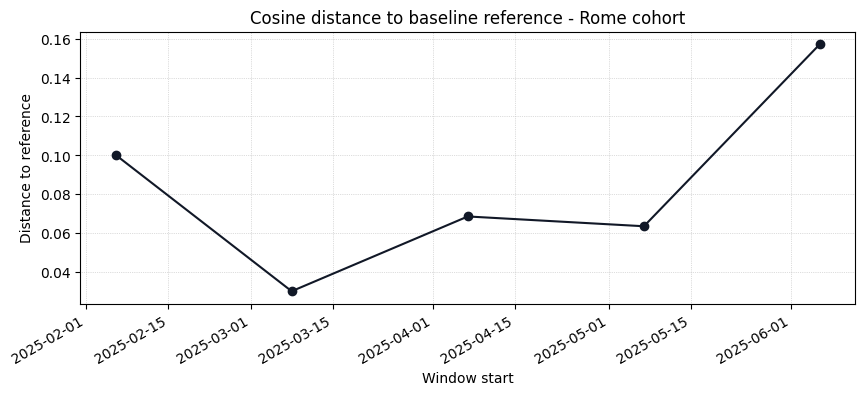

In [5]:
_ = plot_reference_drift(
    ref_df,
    title="Cosine distance to baseline reference - Rome cohort",
)

## 2. PCA Centroid Trajectory

`monitor_pca` projects each window's rows onto a PCA space fitted on
the baseline, then reports the per-window centroid (PC1, PC2) and
dispersion (mean distance from centroid).

`plot_pca_drift` draws arrows between consecutive centroids and colours
each point by time (early → late).

In [6]:
from maldiamrkit.drift import plot_pca_drift

pca_df = monitor.monitor_pca(dataset)
pca_df.head()

,window_start,window_end,centroid_pc1,centroid_pc2,dispersion,n_spectra
0,2025-02-06,2025-03-08,15.638410,7.322260,28.561470,78
1,2025-03-08,2025-04-07,11.465971,0.634700,29.147355,79
2,2025-04-07,2025-05-07,17.153615,2.299735,30.926929,78
3,2025-05-07,2025-06-06,16.887356,-1.988096,35.732134,78
4,2025-06-06,2025-07-06,3.947033,0.726848,33.505330,63


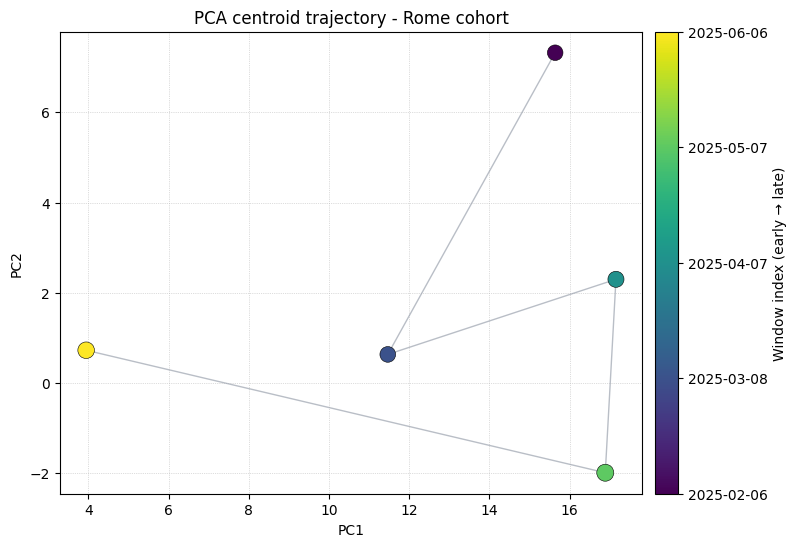

In [7]:
_ = plot_pca_drift(pca_df, title="PCA centroid trajectory - Rome cohort")

## 3. Peak-Selection Stability

For each window, `monitor_peak_stability` fits a fresh
`DifferentialAnalysis` and computes the Jaccard overlap of its top-k
peaks with the baseline top-k. A falling curve means discriminative
peaks are shifting over time - a red flag for biomarker studies.

In [8]:
from maldiamrkit.differential import DifferentialAnalysis
from maldiamrkit.drift import plot_peak_stability

baseline_analysis = DifferentialAnalysis(ordered, meta_full["Amikacin"]).run()
stability_df = monitor.monitor_peak_stability(
    dataset,
    baseline_analysis,
    antibiotic="Amikacin",
    n_top=15,
)
stability_df.head()

,window_start,stability_score,n_spectra
0,2025-02-06,0.000000,78
1,2025-03-08,0.071429,79
2,2025-04-07,0.000000,78
3,2025-05-07,0.000000,78
4,2025-06-06,0.200000,63


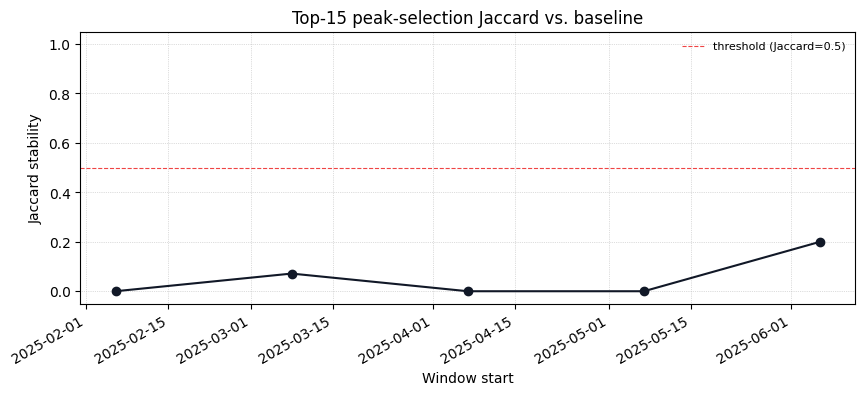

In [9]:
_ = plot_peak_stability(
    stability_df,
    title="Top-15 peak-selection Jaccard vs. baseline",
)

## 4. Per-Peak Effect-Size Drift

If you already have a short list of peaks of interest (e.g., from the
baseline analysis), `monitor_effect_sizes` tracks their Cohen's d
between R and S in each window. A peak whose d drops toward zero (or
flips sign) is losing discriminative power.

In [10]:
from maldiamrkit.drift import plot_effect_size_drift

top5 = baseline_analysis.top_peaks(n=5)["mz_bin"].astype(str).tolist()
effect_df = monitor.monitor_effect_sizes(
    dataset,
    peaks=top5,
    antibiotic="Amikacin",
)
effect_df.head()

,window_start,4703.0,4712.0,4715.0,11114.0,11108.0
0,2025-02-06,0.556368,0.352241,0.450814,0.401412,0.537368
1,2025-03-08,0.715240,0.448572,0.488254,0.763298,0.807354
2,2025-04-07,0.509200,0.468215,0.467595,0.612715,0.360646
3,2025-05-07,0.616484,0.580740,0.681273,0.528699,0.634580
4,2025-06-06,0.752635,0.653076,0.665924,0.785004,0.589966


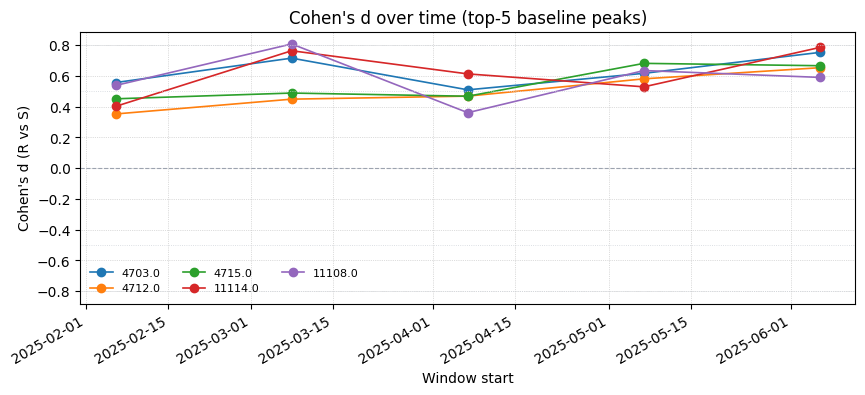

In [11]:
_ = plot_effect_size_drift(
    effect_df,
    title="Cohen's d over time (top-5 baseline peaks)",
)

## See Also

- [API Reference - Drift](https://maldiamrkit.readthedocs.io/en/latest/api/drift.html)
- [Differential Analysis notebook](06_differential_analysis.ipynb)
  for the `DifferentialAnalysis` class that `monitor_peak_stability`
  reuses internally.